# **Chú thích**

**Mục đích của file này là tìm hiểu dữ liệu. Đây là bước khai phá dữ liệu, tìm hiểu về dữ liệu sẽ sử dụng, chưa bao gồm tiền xử lý**

**import**

In [ ]:
import os
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

import re
import unicodedata

# **1. Dữ liệu từ Kaggle**

*Dữ liệu âm thanh được thu thập từ Spotify Dataset (nguồn: Vatsal Mavani – Kaggle)*

## **1.1 Tải dữ liệu**

In [ ]:
import kagglehub
vatsalmavani_spotify_dataset_path = kagglehub.dataset_download('vatsalmavani/spotify-dataset')
print('Kaggle dataset downloaded:', vatsalmavani_spotify_dataset_path)

Using Colab cache for faster access to the 'spotify-dataset' dataset.
Kaggle dataset downloaded: /kaggle/input/spotify-dataset


## **1.2 Đọc dữ liệu**

In [ ]:
data = pd.read_csv(f"{vatsalmavani_spotify_dataset_path}/data/data.csv")
genre_data = pd.read_csv(f"{vatsalmavani_spotify_dataset_path}/data/data_by_genres.csv")
year_data = pd.read_csv(f"{vatsalmavani_spotify_dataset_path}/data/data_by_year.csv")

print("Data shapes:", data.shape, genre_data.shape, year_data.shape)

Data shapes: (170653, 19) (2973, 14) (100, 14)


## **1.3 Khám phá dữ liệu từ Kaggle**

*Dữ liệu được sử dụng chính để khám phá là data.csv*

In [ ]:
# Xem kích thước dữ liệu (số hàng và số cột)
data.shape

(170653, 19)

**Dữ liệu này bao gồm các feature:**
- valence
- year
- acousticness
- artists
- danceability
- duration_ms
- energy
- explicit
- id
- instrumentalness
- key
- liveness
- loudness
- mode
- name
- popularity
- release_date
- speechiness
- tempo

In [ ]:
data.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [ ]:
# Kiểm tra kiểu dữ liệu của từng cột
data.dtypes

,0
valence,float64
year,int64
acousticness,float64
artists,object
danceability,float64
duration_ms,int64
energy,float64
explicit,int64
id,object
instrumentalness,float64


In [ ]:
# kiểm tra null
data.isnull().sum()

,0
valence,0
year,0
acousticness,0
artists,0
danceability,0
duration_ms,0
energy,0
explicit,0
id,0
instrumentalness,0


In [ ]:
spotify_cols = [
    'danceability',
    'energy',
    'valence',
    'acousticness',
    'instrumentalness',
    'speechiness',
    'tempo',
    'loudness',
    'popularity'
]

spotify_df = data[spotify_cols]
spotify_df.describe()


,danceability,energy,valence,acousticness,instrumentalness,speechiness,tempo,loudness,popularity
count,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000
mean,0.537396,0.482389,0.528587,0.502115,0.167010,0.098393,116.861590,-11.467990,31.431794
std,0.176138,0.267646,0.263171,0.376032,0.313475,0.162740,30.708533,5.697943,21.826615
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000
25%,0.415000,0.255000,0.317000,0.102000,0.000000,0.034900,93.421000,-14.615000,11.000000
50%,0.548000,0.471000,0.540000,0.516000,0.000216,0.045000,114.729000,-10.580000,33.000000
75%,0.668000,0.703000,0.747000,0.893000,0.102000,0.075600,135.537000,-7.183000,48.000000
max,0.988000,1.000000,1.000000,0.996000,1.000000,0.970000,243.507000,3.855000,100.000000


**Vẽ phân bố audio features**

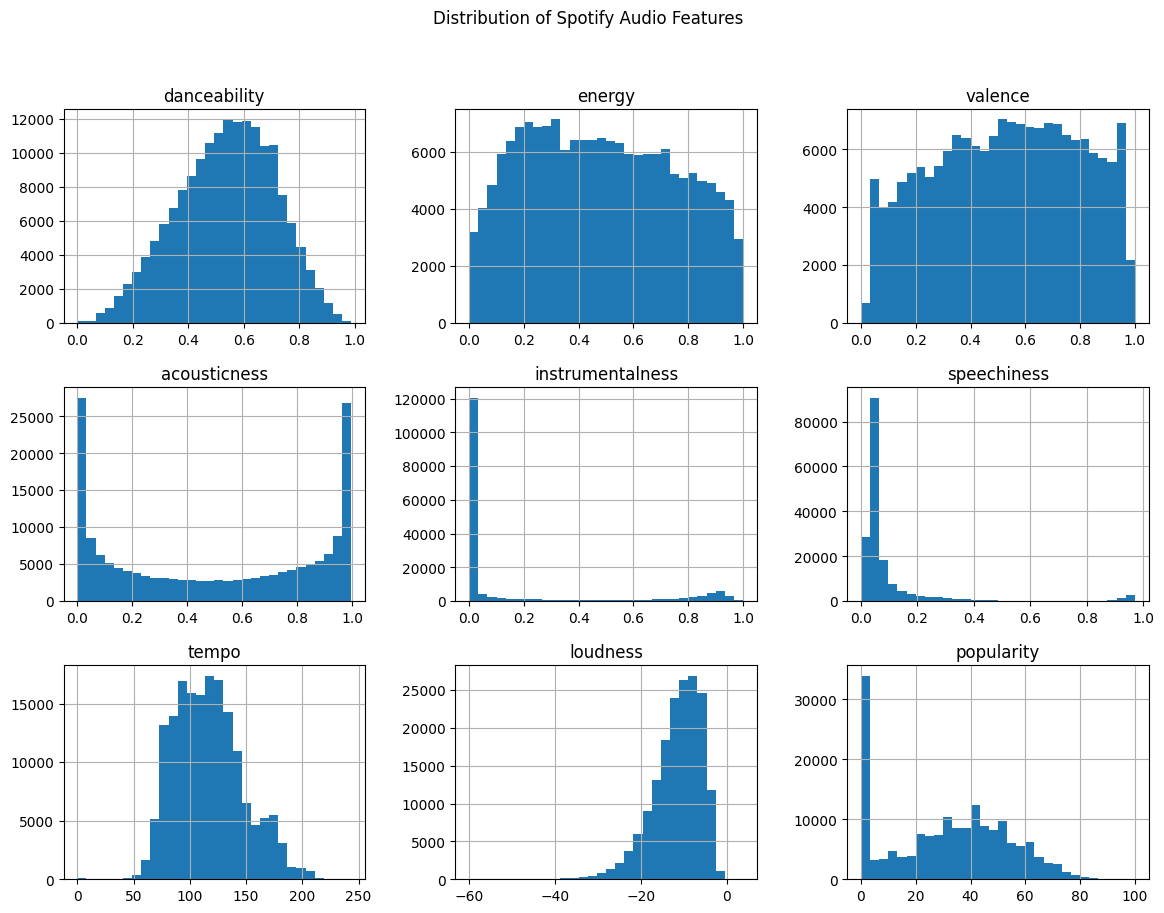

In [ ]:
import matplotlib.pyplot as plt

spotify_df.hist(
    bins=30,
    figsize=(14, 10)
)

plt.suptitle("Distribution of Spotify Audio Features")
plt.show()


# **2. Dữ liệu từ MSD (Million Songs Dataset)**

*Dữ liệu người dùng được lấy từ Million Song Dataset*

## **2.1 The Echo Nest Taste Profile Subset**

### **2.1.1 Taste Profile Subset**

*Dữ liệu chứa thông tin user*

#### **2.1.1.1 Tải Taste Profile Subset (user-song)**

In [ ]:
!wget http://millionsongdataset.com/sites/default/files/challenge/train_triplets.txt.zip -P /content/MSD/

import zipfile
zip_path = "/content/MSD/train_triplets.txt.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/MSD/")

--2026-01-07 08:43:51--  http://millionsongdataset.com/sites/default/files/challenge/train_triplets.txt.zip
Resolving millionsongdataset.com (millionsongdataset.com)... 172.104.14.177
Connecting to millionsongdataset.com (millionsongdataset.com)|172.104.14.177|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 512137572 (488M) [application/zip]
Saving to: ‘/content/MSD/train_triplets.txt.zip’

train_triplets.txt. 100%[===================>] 488.41M  12.7MB/s    in 45s     

2026-01-07 08:44:36 (10.9 MB/s) - ‘/content/MSD/train_triplets.txt.zip’ saved [512137572/512137572]



#### **2.1.1.2 Đọc dữ liệu**

In [ ]:
file_path = "/content/MSD/train_triplets.txt"
tp = pd.read_csv(
    file_path,
    sep='\t',
    names=['user_id', 'song_id', 'play_count'])

print("Taste Profile loaded:", tp.shape) # (48373586, 3)

Taste Profile loaded: (48373586, 3)


#### **2.1.1.3 Khám phá dữ liệu**

In [ ]:
# Xem kích thước dữ liệu (số hàng và số cột)
tp.shape

(48373586, 3)

**Dữ liệu Taste Profile Subnet có các feature:**
- user_id
- song_id
- play_count

In [ ]:
tp.head()

,user_id,song_id,play_count
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAPDEY12A81C210A9,1
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFNSP12AF72A0E22,1
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFOVM12A58A7D494,1


In [ ]:
# Kiểm tra kiểu dữ liệu của từng cột
tp.dtypes

,0
user_id,object
song_id,object
play_count,int64


In [ ]:
# kiểm tra null
tp.isnull().sum()

,0
user_id,0
song_id,0
play_count,0


In [ ]:
print(f"- Tổng số user: {tp['user_id'].nunique():,}")
print(f"- Tổng số bài hát: {tp['song_id'].nunique():,}")

- Tổng số user: 1,019,318
- Tổng số bài hát: 384,546


In [ ]:
tp['play_count'].describe()

,play_count
count,4.837359e+07
mean,2.866859e+00
std,6.437725e+00
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,3.000000e+00
max,9.667000e+03


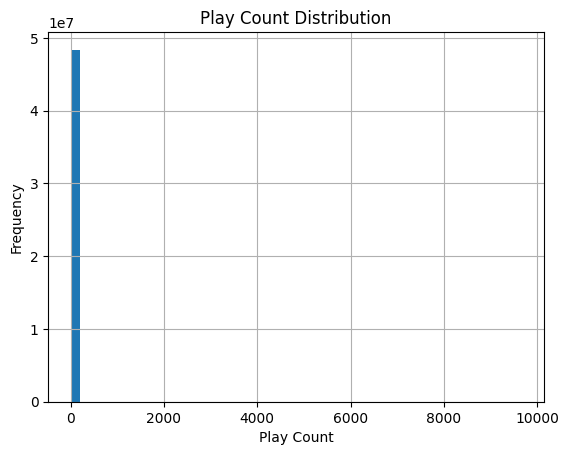

In [ ]:
tp['play_count'].hist(bins=50)
plt.title("Play Count Distribution")
plt.xlabel("Play Count")
plt.ylabel("Frequency")
plt.show()


*--> Phân bố số lượt phát nhạc có độ lệch rất lớn (Long-tail distribution)*

**Số bài / user**

In [ ]:
songs_per_user = tp.groupby('user_id')['song_id'].nunique()

songs_per_user.describe()


,song_id
count,1.019318e+06
mean,4.745682e+01
std,5.781573e+01
min,1.000000e+01
25%,1.600000e+01
50%,2.700000e+01
75%,5.500000e+01
max,4.400000e+03


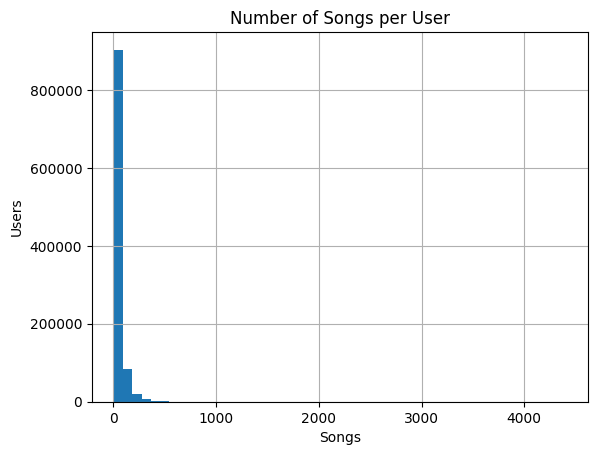

In [ ]:
songs_per_user.hist(bins=50)
plt.title("Number of Songs per User")
plt.xlabel("Songs")
plt.ylabel("Users")
plt.show()


**Số user / bài**

In [ ]:
users_per_song = tp.groupby('song_id')['user_id'].nunique()

users_per_song.describe()


,user_id
count,384546.000000
mean,125.794017
std,799.025834
min,1.000000
25%,4.000000
50%,13.000000
75%,52.000000
max,110479.000000


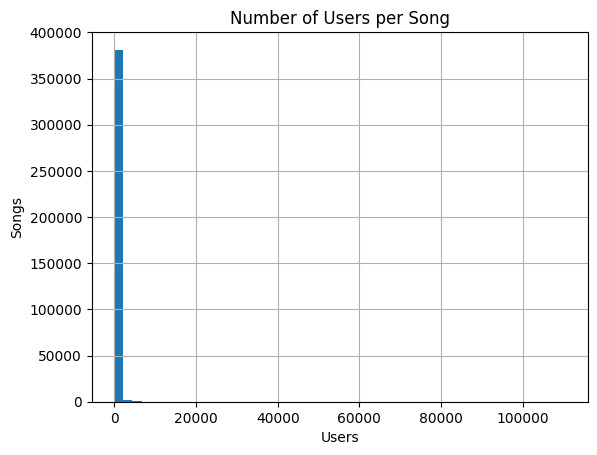

In [ ]:
users_per_song.hist(bins=50)
plt.title("Number of Users per Song")
plt.xlabel("Users")
plt.ylabel("Songs")
plt.show()


*--> Hầu hết người dùng chỉ tương tác với một số lượng nhỏ các bài hát, trong khi một số ít người dùng lại nghe hàng nghìn bài hát.*

*Dữ liệu song_id giữa Kaggle và Taste Profile Subnet của MSD có sự khác biệt về định dạng. Nên cần có 1 file để kết nối chúng lại thông qua artist.*

### **2.1.2 Tracking**

*Dữ liệu chứa thông tin tracking*

#### **2.1.2.1 Tải Tracking (dùng để mapping dữ liệu)**

In [ ]:
!wget http://millionsongdataset.com/sites/default/files/AdditionalFiles/unique_tracks.txt -P /content/MSD/

--2026-01-07 08:47:45--  http://millionsongdataset.com/sites/default/files/AdditionalFiles/unique_tracks.txt
Resolving millionsongdataset.com (millionsongdataset.com)... 172.104.14.177
Connecting to millionsongdataset.com (millionsongdataset.com)|172.104.14.177|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84046293 (80M) [text/plain]
Saving to: ‘/content/MSD/unique_tracks.txt’

unique_tracks.txt   100%[===================>]  80.15M  9.76MB/s    in 9.0s    

2026-01-07 08:47:54 (8.88 MB/s) - ‘/content/MSD/unique_tracks.txt’ saved [84046293/84046293]



#### **2.1.2.2 Đọc dữ liệu**

In [ ]:
tracks = pd.read_csv(
    "/content/MSD/unique_tracks.txt",
    sep='<SEP>',
    header=None,
    names=['track_id', 'song_id', 'artist_name', 'title'],
    engine='python'
)

print("Unique tracks loaded:", tracks.shape) #(1000000, 4)

Unique tracks loaded: (1000000, 4)


#### **2.1.2.3 Khám phá dữ liệu**

In [ ]:
# Xem kích thước dữ liệu (số hàng và số cột)
tracks.shape

(1000000, 4)

**Dữ liệu Tracking có các feature:**
- track_id
- song_id
- artist_name
- title


In [ ]:
tracks.head()

,track_id,song_id,artist_name,title
0,TRMMMYQ128F932D901,SOQMMHC12AB0180CB8,Faster Pussy cat,Silent Night
1,TRMMMKD128F425225D,SOVFVAK12A8C1350D9,Karkkiautomaatti,Tanssi vaan
2,TRMMMRX128F93187D9,SOGTUKN12AB017F4F1,Hudson Mohawke,No One Could Ever
3,TRMMMCH128F425532C,SOBNYVR12A8C13558C,Yerba Brava,Si Vos Querés
4,TRMMMWA128F426B589,SOHSBXH12A8C13B0DF,Der Mystic,Tangle Of Aspens


In [ ]:
# Kiểm tra kiểu dữ liệu của từng cột
tracks.dtypes

,0
track_id,object
song_id,object
artist_name,object
title,object


In [ ]:
# Kiểm tra null
tracks.isnull().sum()

,0
track_id,0
song_id,0
artist_name,0
title,17


*Giải quyết null*

In [ ]:
tracks.dropna(inplace=True)
tracks.isnull().sum()

,0
track_id,0
song_id,0
artist_name,0
title,0


In [ ]:
tracks.shape

(999983, 4)

## **2.2 The musiXmatch Dataset**

### **2.2.1 Tải và giải nén**

In [ ]:
!wget http://millionsongdataset.com/sites/default/files/AdditionalFiles/mxm_dataset_train.txt.zip -P /content/MSD/
!wget http://millionsongdataset.com/sites/default/files/AdditionalFiles/mxm_dataset_test.txt.zip -P /content/MSD/

--2026-01-07 08:48:02--  http://millionsongdataset.com/sites/default/files/AdditionalFiles/mxm_dataset_train.txt.zip
Resolving millionsongdataset.com (millionsongdataset.com)... 172.104.14.177
Connecting to millionsongdataset.com (millionsongdataset.com)|172.104.14.177|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36502856 (35M) [application/zip]
Saving to: ‘/content/MSD/mxm_dataset_train.txt.zip’

mxm_dataset_train.t 100%[===================>]  34.81M  7.66MB/s    in 5.2s    

2026-01-07 08:48:08 (6.69 MB/s) - ‘/content/MSD/mxm_dataset_train.txt.zip’ saved [36502856/36502856]

--2026-01-07 08:48:08--  http://millionsongdataset.com/sites/default/files/AdditionalFiles/mxm_dataset_test.txt.zip
Resolving millionsongdataset.com (millionsongdataset.com)... 172.104.14.177
Connecting to millionsongdataset.com (millionsongdataset.com)|172.104.14.177|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4798712 (4.6M) [application/zip]
Saving to: ‘/

In [ ]:
import zipfile
zip_path = "/content/MSD/mxm_dataset_train.txt.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/MSD/")

In [ ]:
import zipfile
zip_path = "/content/MSD/mxm_dataset_test.txt.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/MSD/")

### **2.2.2 Đọc và lưu dữ liệu**

In [ ]:
import pandas as pd
import os

input_files = [
    "/content/MSD/mxm_dataset_train.txt",
    "/content/MSD/mxm_dataset_test.txt"
]

output_path = "/content/MSD/lyrics_track_ids.txt"
chunk_size = 1000

vocab = []


In [ ]:
def load_checkpoint(file_path):
    cp = file_path.replace('.txt', '_checkpoint.txt')
    try:
        with open(cp, 'r') as f:
            return int(f.read().strip())
    except:
        return 0

def save_checkpoint(file_path, line_num):
    cp = file_path.replace('.txt', '_checkpoint.txt')
    with open(cp, 'w') as f:
        f.write(str(line_num))

In [ ]:
def process_mxm_file(file_path):
    global vocab

    start_line = load_checkpoint(file_path)
    print(f"Resume from line {start_line}")

    buffer = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f):
            if line_num < start_line:
                continue

            line = line.strip()

            if line.startswith('#'):
                continue

            if line.startswith('%'):
                if not vocab:
                    vocab = line[1:].split(',')
                continue

            parts = line.split(',')
            track_id = parts[0]

            # Build pseudo-lyrics
            words = []
            for wc in parts[2:]:
                if ':' not in wc:
                    continue
                wid, cnt = wc.split(':')
                wid = int(wid) - 1
                cnt = int(cnt)

                words.extend([vocab[wid]] * cnt)

            lyrics_text = " ".join(words)

            buffer.append({
                'track_id': track_id,
                'lyrics': lyrics_text
            })

            if len(buffer) >= chunk_size:
                pd.DataFrame(buffer).to_csv(
                    output_path,
                    mode='a',
                    header=not os.path.exists(output_path),
                    index=False
                )
                buffer = []
                save_checkpoint(file_path, line_num)
                print(f"Saved up to line {line_num}")

    if buffer:
        pd.DataFrame(buffer).to_csv(
            output_path,
            mode='a',
            header=not os.path.exists(output_path),
            index=False
        )
        save_checkpoint(file_path, line_num)

In [ ]:
for file_path in input_files:
    process_mxm_file(file_path)

df_lyrics = pd.read_csv(output_path)
print("Total tracks:", len(df_lyrics))

Resume from line 0
Saved up to line 1017
Saved up to line 2017
Saved up to line 3017
Saved up to line 4017
Saved up to line 5017
Saved up to line 6017
Saved up to line 7017
Saved up to line 8017
Saved up to line 9017
Saved up to line 10017
Saved up to line 11017
Saved up to line 12017
Saved up to line 13017
Saved up to line 14017
Saved up to line 15017
Saved up to line 16017
Saved up to line 17017
Saved up to line 18017
Saved up to line 19017
Saved up to line 20017
Saved up to line 21017
Saved up to line 22017
Saved up to line 23017
Saved up to line 24017
Saved up to line 25017
Saved up to line 26017
Saved up to line 27017
Saved up to line 28017
Saved up to line 29017
Saved up to line 30017
Saved up to line 31017
Saved up to line 32017
Saved up to line 33017
Saved up to line 34017
Saved up to line 35017
Saved up to line 36017
Saved up to line 37017
Saved up to line 38017
Saved up to line 39017
Saved up to line 40017
Saved up to line 41017
Saved up to line 42017
Saved up to line 43017
S

### **2.2.3 Khám phá dữ liệu**

In [ ]:
# Xem kích thước dữ liệu (số hàng và số cột)
df_lyrics.shape

(237662, 2)

**Dữ liệu MXM chứa các features:**
- track_id
- lyrics

**Lưu ý: lời bài hát được tái tạo dưới dạng chuỗi từ không theo thứ tự từ mô hình Bag-of-Words,vốn không giữ nguyên thứ tự từ hoặc tần suất xuất hiện ban đầu.**

In [ ]:
df_lyrics.head()

,track_id,lyrics
0,TRAAAAV128F421A322,i i i i i i the the the the you you to to and ...
1,TRAAABD128F429CF47,i i i i i i i i i i you you you you you you yo...
2,TRAAAED128E0783FAB,i i i i i i i i i i i i i i i i i i i i i i i ...
3,TRAAAEF128F4273421,i i i i i the the the the you you you to to an...
4,TRAAAEW128F42930C0,i i i i to to to to to and and and and and and...


In [ ]:
# Kiểm tra kiểu dữ liệu của từng cột
df_lyrics.dtypes

,0
track_id,object
lyrics,object


In [ ]:
# Kiểm tra null
df_lyrics.isnull().sum()

,0
track_id,0
lyrics,0


**Độ dài lyrics (word count)**

In [ ]:
df_lyrics['word_count'] = df_lyrics['lyrics'].str.split().str.len()
df_lyrics['word_count'].describe()

,word_count
count,237662.000000
mean,212.939309
std,137.802579
min,1.000000
25%,126.000000
50%,187.000000
75%,265.000000
max,8578.000000


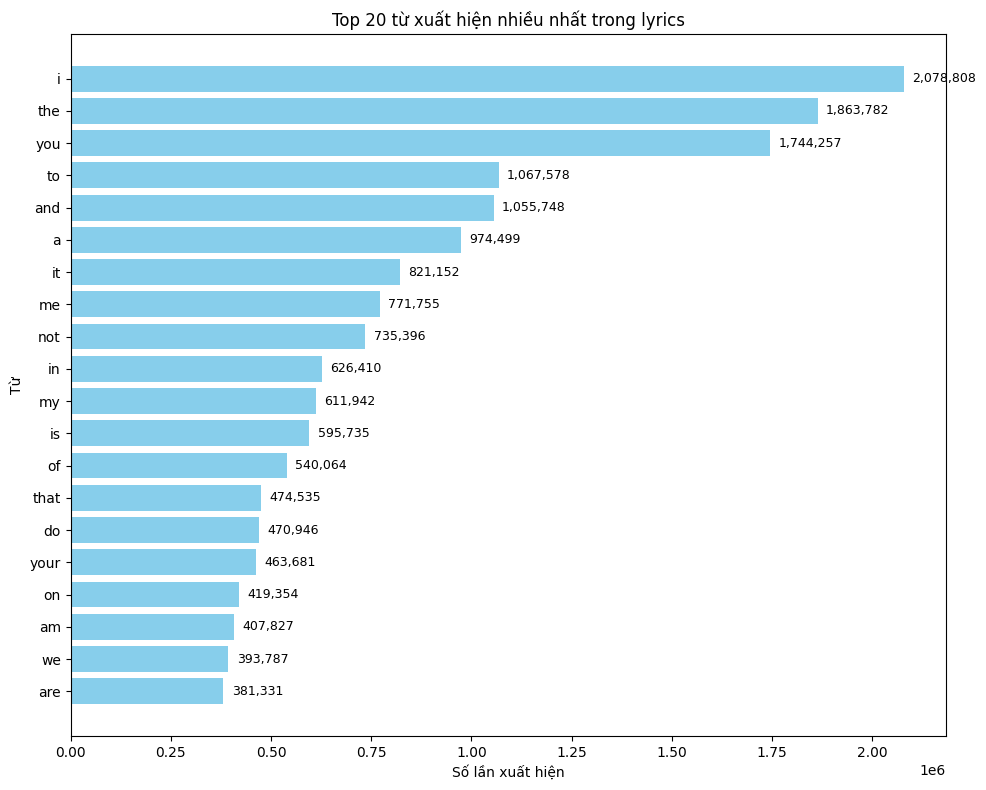

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


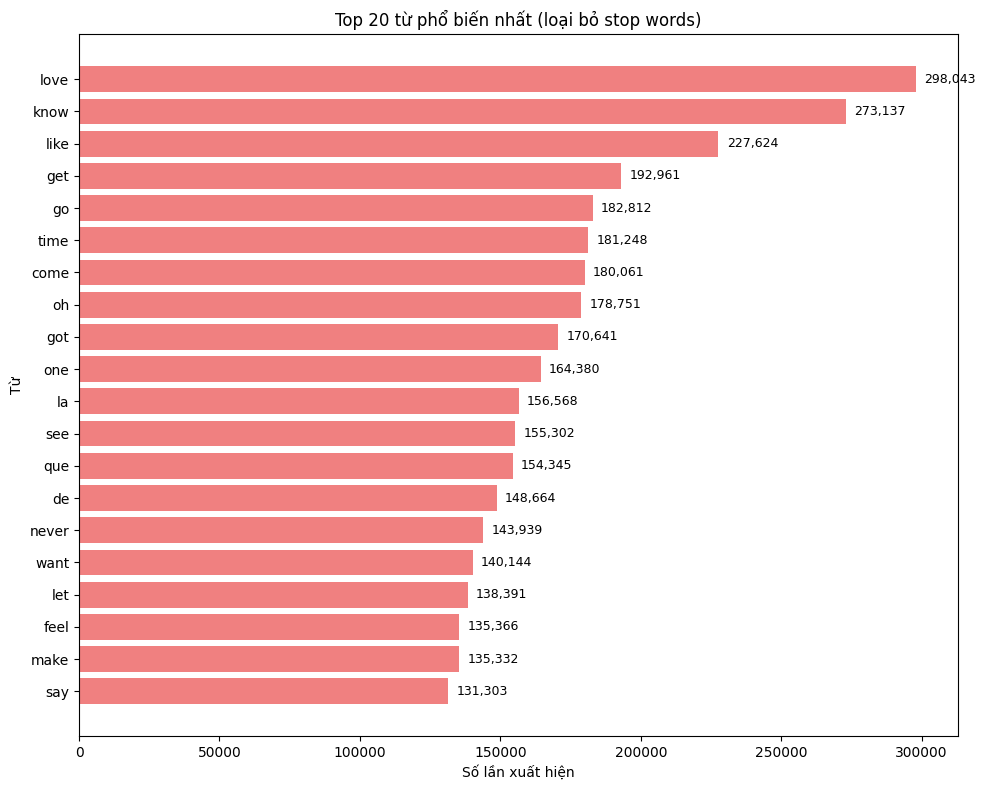

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_top_words(word_freq, title, color='skyblue', top_n=20):
    top = word_freq.most_common(top_n)
    words = [word for word, count in top[::-1]]
    counts = [count for word, count in top[::-1]]

    plt.figure(figsize=(10, 8))
    bars = plt.barh(words, counts, color=color)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{int(width):,}', va='center', fontsize=9)

    plt.xlabel('Số lần xuất hiện')
    plt.ylabel('Từ')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Có stop words
all_words = " ".join(df_lyrics['lyrics'].astype(str)).split()
word_freq = Counter(all_words)
plot_top_words(word_freq, 'Top 20 từ xuất hiện nhiều nhất trong lyrics', 'skyblue')

# Loại stop words
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

filtered_words = [word for word in all_words if word.lower() not in stop_words]
word_freq_filtered = Counter(filtered_words)
plot_top_words(word_freq_filtered, 'Top 20 từ phổ biến nhất (loại bỏ stop words)', 'lightcoral')